# Install dependencies and environment setup


In [31]:
%pip -qqq install miditoolkit kagglehub scikit-learn torch pandarallel

In [32]:
# Dependencies
from __future__ import annotations
from collections import OrderedDict

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

from bisect import bisect_right
import copy
import glob
import hashlib
import time
import json
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
from miditoolkit import MidiFile
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

In [33]:
from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [34]:
# Check if PyTorch can access an NVIDIA GPU through CUDA
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


# Import Dataset from Kaggle


In [35]:
# Download dataset
directory = kagglehub.dataset_download(
  "blanderbuss/midi-classic-music"
)

Using Colab cache for faster access to the 'midi-classic-music' dataset.


# Restructure and filter midi_files

Filter for Bach, Beethoven, Chopin, and Mozart midi files only


In [36]:
# Search for MIDI (.mid) files belonging to 4 composers
def read_midi_files(composers):
  midi_files = []
  for composer in composers:
    midi_filenames = sorted(
            set(
                glob.glob(
                    f"{directory}/midiclassics/{composer}/**/*.mid",
                    recursive=True)))

    print(f'Found {len(midi_filenames)} .mid files for {composer}')

    midi_files += [{
        'composer': composer,
        'filename': filename
    } for filename in midi_filenames]

  df = pd.DataFrame(midi_files)
  return df

df = read_midi_files(['Bach', 'Beethoven', 'Chopin', 'Mozart'])

def file_sha1(filename):
    hasher = hashlib.sha1()
    with open(filename, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

df["content_hash"] = df["filename"].apply(file_sha1)

conflicts = df.groupby("content_hash")["composer"].nunique()
if (conflicts > 1).any():
    raise ValueError("Identical MIDI files have different composer labels.")

duplicates_removed = df.duplicated("content_hash").sum()
df = df.drop_duplicates("content_hash").reset_index(drop=True)

print("Duplicate MIDI files removed:", duplicates_removed)

df

Found 925 .mid files for Bach
Found 212 .mid files for Beethoven
Found 136 .mid files for Chopin
Found 257 .mid files for Mozart
Duplicate MIDI files removed: 20


,composer,filename,content_hash
0,Bach,/kaggle/input/midi-classic-music/midiclassics/...,e446e98103f7ec72f2c5b460872820382d6b5007
1,Bach,/kaggle/input/midi-classic-music/midiclassics/...,a621bc47a2dbe378166f6fbc40b449a9b12e3e87
2,Bach,/kaggle/input/midi-classic-music/midiclassics/...,d9fb174748d091ee217073189ebc2335117a9c15
3,Bach,/kaggle/input/midi-classic-music/midiclassics/...,32a8b534b984c883a6f981bde0c3a3585807f9cb
4,Bach,/kaggle/input/midi-classic-music/midiclassics/...,64e021019b49423494aca373ae1b0634a2d0c1e5
...,...,...,...
1505,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,dcb1b02523bd3ebe383c8ad0ce144a6e2fd0ecc9
1506,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,ec2057838f086123fbdf7a3d6e3fdcea41491d6c
1507,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,58ec5eb3e56a270cbb5d10f0d0aa0565ca37b465
1508,Mozart,/kaggle/input/midi-classic-music/midiclassics/...,2005cf54eccf37620a524506c4bcf7af8eb7392e


## Data pre-processing and feature extraction

The downloaded `midiclassics` dataset contains composer-specific directories, including nested subdirectories. MIDI files for Bach, Beethoven, Chopin, and Mozart are located recursively and exact content duplicates are removed.

Each MIDI file is converted into an ordered sequence of note events. The extracted features are:

- pitch
- pitch class
- duration in beats
- normalized velocity
- onset spacing in beats
- MIDI instrument program
- tempo
- time-signature numerator
- time-signature denominator

Source-level training, validation, and test splits are created later using stratification by composer.


### DATA PRE-PROCESSING, MIDI CONVERSION, AUGMENTATION, AND EVENT FEATURE EXTRACTION

Symbolic-music models commonly represent a score as an ordered sequence of note events. MusicBERT’s OctupleMIDI representation demonstrates the usefulness of metrical position, instrument, pitch, duration, velocity, tempo, and time signature for symbolic-music understanding (Zeng et al., 2021). Inspired by this event-based representation, this notebook extracts pitch, pitch class, duration, velocity, onset spacing, instrument program, tempo, and meter.

MIDI files are parsed, and online pitch transposition from −2 to +2 semitones is applied only to training crops. Validation and test sequences remain unchanged. Controlled transformations of symbolic MIDI have also been explored in prior work (McLeod et al., 2020). Augmentation is applied only after the source-level split, and all variants sharing the same content-based `source_id` remain in the training partition to prevent data leakage.

### APA 7 references

McLeod, A., Owers, J., & Yoshii, K. (2020). The MIDI degradation toolkit:
Symbolic music augmentation and correction. arXiv.
https://doi.org/10.48550/arXiv.2010.00059

Zeng, M., Tan, X., Wang, R., Ju, Z., Qin, T., & Liu, T.-Y. (2021).
MusicBERT: Symbolic music understanding with large-scale pre-training.
In Findings of the Association for Computational Linguistics:
ACL-IJCNLP 2021 (pp. 791–800).
https://doi.org/10.18653/v1/2021.findings-acl.70


In [37]:
# Parse source MIDI files, extract event-level note features, and build a
# leakage-safe dataset. Training-time augmentation is applied only by the data loader.
def stable_source_id(path):
    return file_sha1(path)[:16]


def _active_tempo(tick: int, tempo_ticks: list[int], tempo_values: list[float]) -> float:
    """Return the most recent tempo at a note onset."""
    idx = max(0, bisect_right(tempo_ticks, tick) - 1)
    return tempo_values[idx]


def _active_meter_index(tick: int, meter_ticks: list[int]) -> int:
    return max(0, bisect_right(meter_ticks, tick) - 1)


def extract_event_features(midi_path: str | Path) -> dict:
    """Convert a MIDI file into chronological, texture-aware note-event features."""
    midi = MidiFile(str(midi_path))
    tpq = max(int(midi.ticks_per_beat), 1)

    tempo_changes = sorted(midi.tempo_changes, key=lambda x: x.time)
    tempo_ticks = [int(x.time) for x in tempo_changes] or [0]
    tempo_values = [float(x.tempo) for x in tempo_changes] or [120.0]

    meter_changes = sorted(midi.time_signature_changes, key=lambda x: x.time)
    meter_ticks = [int(x.time) for x in meter_changes] or [0]
    numerators = [int(x.numerator) for x in meter_changes] or [4]
    denominators = [int(x.denominator) for x in meter_changes] or [4]

    raw_events = []
    for instrument in midi.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            raw_events.append((
                int(note.start), int(note.end), int(note.pitch),
                int(note.velocity), int(instrument.program),
            ))

    raw_events.sort(key=lambda event: (event[0], event[2], event[1]))
    features = []
    active_end_ticks = []
    previous_start = raw_events[0][0] if raw_events else 0
    previous_pitch = raw_events[0][2] if raw_events else 0
    event_index = 0

    while event_index < len(raw_events):
        start = raw_events[event_index][0]
        onset_events = []
        while event_index < len(raw_events) and raw_events[event_index][0] == start:
            onset_events.append(raw_events[event_index])
            event_index += 1

        active_end_ticks = [end for end in active_end_ticks if end > start]
        pitches = [event[2] for event in onset_events]
        chord_size = len(onset_events)
        chord_span = max(pitches) - min(pitches)
        meter_index = _active_meter_index(start, meter_ticks)
        numerator = numerators[meter_index]
        denominator = denominators[meter_index]
        ticks_per_measure = max(tpq * 4 * numerator / denominator, 1.0)
        measure_phase = ((start - meter_ticks[meter_index]) % ticks_per_measure) / ticks_per_measure
        onset_delta_beats = max(start - previous_start, 0) / tpq

        for chord_rank, (note_start, end, pitch, velocity, program) in enumerate(onset_events):
            duration_beats = max(end - note_start, 1) / tpq
            pitch_interval = pitch - previous_pitch if features else 0
            rank_fraction = chord_rank / max(chord_size - 1, 1)

            features.append({
                "pitch": pitch,
                "pitch_class": pitch % 12,
                "pitch_interval": pitch_interval,
                "absolute_pitch_interval": abs(pitch_interval),
                "log_duration_beats": np.log1p(duration_beats),
                "velocity": velocity / 127.0,
                "log_onset_delta_beats": np.log1p(onset_delta_beats),
                "beat_position": measure_phase,
                "beat_phase_sin": np.sin(2.0 * np.pi * measure_phase),
                "beat_phase_cos": np.cos(2.0 * np.pi * measure_phase),
                "chord_size": chord_size,
                "chord_span": chord_span,
                "active_note_count": len(active_end_ticks),
                "chord_rank": rank_fraction,
                "program": program,
                "tempo_bpm": _active_tempo(note_start, tempo_ticks, tempo_values),
                "time_signature_numerator": numerator,
                "time_signature_denominator": denominator,
            })
            previous_pitch = pitch

        active_end_ticks.extend(event[1] for event in onset_events)
        previous_start = start

    return {
        "event_features": features,
        "sequence_length": len(features),
        "ticks_per_beat": tpq,
    }


def process_single_midi_row(row):
    try:
        midi_path = Path(row.filename)
        source_id = stable_source_id(row.filename)

        extracted = extract_event_features(midi_path)

        return {
            "composer": row.composer,
            "source_id": source_id,
            "augmentation": "original",
            "pitch_shift": 0,
            "tempo_factor": 1.0,
            "midi_path": str(midi_path),
            **extracted,
        }
    except Exception as exc:
        print(f"Skipped {row.filename}: {exc}")
        return None


def build_preprocessed_dataset(source_df: pd.DataFrame) -> pd.DataFrame:
    """Read source MIDI files and extract original event sequences using parallel_apply."""
    results = source_df.parallel_apply(process_single_midi_row, axis=1)
    valid_results = results.dropna()
    if valid_results.empty:
        return pd.DataFrame()

    return pd.DataFrame(valid_results.tolist())

In [38]:
# Preprocess original MIDI files only.
# Source-level splitting and training-only augmentation are performed later to
# prevent augmented versions of the same piece appearing in multiple splits.

processed_df = build_preprocessed_dataset(df)

print(f"Created {len(processed_df):,} original sequences.")
display(
    processed_df[
        ["composer", "source_id", "augmentation", "sequence_length", "midi_path"]
    ].head()
)
print("\nClass counts:")
display(processed_df["composer"].value_counts())

Skipped /kaggle/input/midi-classic-music/midiclassics/Beethoven/Anhang 14-3.mid: Could not decode key with 3 flats and mode 255
Skipped /kaggle/input/midi-classic-music/midiclassics/Mozart/Piano Sonatas/Nueva carpeta/K281 Piano Sonata n03 3mov.mid: Could not decode key with 2 flats and mode 2
Created 1,508 original sequences.


,composer,source_id,augmentation,sequence_length,midi_path
0,Bach,e446e98103f7ec72,original,793,/kaggle/input/midi-classic-music/midiclassics/...
1,Bach,a621bc47a2dbe378,original,524,/kaggle/input/midi-classic-music/midiclassics/...
2,Bach,d9fb174748d091ee,original,428,/kaggle/input/midi-classic-music/midiclassics/...
3,Bach,32a8b534b984c883,original,418,/kaggle/input/midi-classic-music/midiclassics/...
4,Bach,64e021019b494234,original,622,/kaggle/input/midi-classic-music/midiclassics/...



Class counts:


,count
composer,
Bach,915
Mozart,254
Beethoven,207
Chopin,132


### Dataset formatting, leakage-safe splitting, and NumPy serialization

This section converts the event dictionaries in `processed_df` into variable-length numerical event arrays. Splits are performed at the unique original MIDI-source level using a content-based `source_id`, with stratification by composer. Exact duplicate MIDI files are removed before splitting. Online augmentation is applied only to training crops, while validation and test data remain unchanged.

Generated artifacts:

- `X_train`, `X_val`, `X_test`: lists of event arrays with shape `(events, features)`
- `y_train`, `y_val`, `y_test`: integer composer labels
- compressed `.npz` split files, a label map, a feature specification, and CSV manifests

Fixed-size crops and valid-event masks are created later by the data loader.

In [39]:
# Reproducible split configuration.
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

# Base feature order used by preprocessing and model-specific data loaders.
# Meter is represented by derived phase features rather than raw time-signature fields.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_position",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
    "chord_rank",
]

SERIALIZED_DIR = Path("serialized_dataset")
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)


def validate_processed_dataframe(dataframe: pd.DataFrame) -> None:
    """Check that preprocessing created the columns required below."""
    required = {"composer", "source_id", "augmentation", "event_features"}
    missing = required.difference(dataframe.columns)
    if missing:
        raise ValueError(
            "processed_df is missing required columns: " + ", ".join(sorted(missing))
        )
    if dataframe.empty:
        raise ValueError("processed_df is empty; run the preprocessing cell first.")


def make_source_level_splits(dataframe: pd.DataFrame):
    """Split unique original sources with composer stratification."""
    source_table = (
        dataframe[["source_id", "composer"]]
        .drop_duplicates()
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )

    conflicts = source_table.groupby("source_id")["composer"].nunique()
    if (conflicts > 1).any():
        bad_ids = conflicts[conflicts > 1].index.tolist()[:5]
        raise ValueError(f"Some source IDs have multiple composer labels: {bad_ids}")

    class_counts = source_table["composer"].value_counts()
    if (class_counts < 3).any():
        raise ValueError(
            "Each composer needs at least three original files for train/validation/test "
            f"splitting. Counts: {class_counts.to_dict()}"
        )

    train_sources, temp_sources = train_test_split(
        source_table,
        train_size=TRAIN_SIZE,
        random_state=RANDOM_STATE,
        stratify=source_table["composer"],
    )

    relative_test_size = TEST_SIZE / (VALIDATION_SIZE + TEST_SIZE)
    val_sources, test_sources = train_test_split(
        temp_sources,
        test_size=relative_test_size,
        random_state=RANDOM_STATE,
        stratify=temp_sources["composer"],
    )

    return train_sources, val_sources, test_sources


def select_rows_for_split(
    dataframe: pd.DataFrame,
    source_table: pd.DataFrame,
) -> pd.DataFrame:
    """Select original source rows for one leakage-safe partition."""
    return (
        dataframe[dataframe["source_id"].isin(source_table["source_id"])]
        .sort_values(["composer", "source_id"])
        .reset_index(drop=True)
    )


def encode_and_format(split_df: pd.DataFrame, label_to_index: dict):
    """Create unnormalized event arrays and integer labels for one split."""
    sequences = []
    for events_list in split_df["event_features"].tolist():
        sequence = [
            [event.get(feature_name, 0.0) for feature_name in FEATURE_NAMES]
            for event in events_list
        ]
        sequences.append(
            np.asarray(sequence, dtype=np.float32).reshape(-1, len(FEATURE_NAMES))
        )

    encoded = split_df["composer"].map(label_to_index)
    if encoded.isna().any():
        unknown = split_df.loc[encoded.isna(), "composer"].unique().tolist()
        raise ValueError(f"Unknown composer labels: {unknown}")

    return sequences, encoded.to_numpy(dtype=np.int64)


def fit_feature_normalizer(train_sequences):
    """Fit robust feature statistics using training events only."""
    nonempty_sequences = [sequence for sequence in train_sequences if len(sequence)]
    if not nonempty_sequences:
        raise ValueError("Training split has no valid note events.")

    train_events = np.concatenate(nonempty_sequences, axis=0)
    center = np.median(train_events, axis=0).astype(np.float32)
    lower = np.percentile(train_events, 25, axis=0)
    upper = np.percentile(train_events, 75, axis=0)
    scale = np.maximum(upper - lower, 0.01).astype(np.float32)
    return center, scale


def save_split(name, X, y, manifest: pd.DataFrame):
    """Serialize arrays as compressed NPZ and metadata as CSV."""
    np.savez_compressed(
        SERIALIZED_DIR / f"{name}.npz",
        X_sequences=np.array(X, dtype=object),
        y=y,
        feature_names=np.asarray(FEATURE_NAMES),
    )
    manifest_columns = [
        column for column in
        ["composer", "source_id", "augmentation", "midi_path", "sequence_length"]
        if column in manifest.columns
    ]
    manifest[manifest_columns].to_csv(
        SERIALIZED_DIR / f"{name}_manifest.csv", index=False
    )

In [40]:
# Retain a complete base tensor so experimental features stay available for future work.
# Each model receives its validated subset in make_loaders.
FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_position",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
    "chord_rank",
]
CNN_FEATURE_NAMES = [
    "pitch",
    "pitch_class",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "velocity",
    "log_onset_delta_beats",
    "beat_phase_sin",
    "beat_phase_cos",
    "chord_size",
    "chord_span",
    "active_note_count",
]
LSTM_FEATURE_NAMES = [
    "pitch",
    "pitch_interval",
    "absolute_pitch_interval",
    "log_duration_beats",
    "log_onset_delta_beats",
    "beat_position",
    "chord_span",
    "active_note_count",
    "chord_rank",
]
MODEL_FEATURE_NAMES = {
    "CNN": CNN_FEATURE_NAMES,
    "LSTM": LSTM_FEATURE_NAMES,
}

print("Base features:", FEATURE_NAMES)
for model_name, feature_names in MODEL_FEATURE_NAMES.items():
    print(f"{model_name} features ({len(feature_names)}):", feature_names)

Base features: ['pitch', 'pitch_class', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'velocity', 'log_onset_delta_beats', 'beat_position', 'beat_phase_sin', 'beat_phase_cos', 'chord_size', 'chord_span', 'active_note_count', 'chord_rank']
CNN features (12): ['pitch', 'pitch_class', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'velocity', 'log_onset_delta_beats', 'beat_phase_sin', 'beat_phase_cos', 'chord_size', 'chord_span', 'active_note_count']
LSTM features (9): ['pitch', 'pitch_interval', 'absolute_pitch_interval', 'log_duration_beats', 'log_onset_delta_beats', 'beat_position', 'chord_span', 'active_note_count', 'chord_rank']


In [41]:
# Create leakage-safe source-level splits, encode original source sequences into
# variable-length event arrays, and save the data and metadata. Class balance is handled by
# the source-balanced training sampler, not duplicate offline variants.
def calculate_total_nbytes(list_of_arrays):
    return sum(array.nbytes for array in list_of_arrays)


validate_processed_dataframe(processed_df)
train_sources, val_sources, test_sources = make_source_level_splits(processed_df)

train_df = select_rows_for_split(processed_df, train_sources)
val_df = select_rows_for_split(processed_df, val_sources)
test_df = select_rows_for_split(processed_df, test_sources)

assert set(train_df["source_id"]).isdisjoint(val_df["source_id"])
assert set(train_df["source_id"]).isdisjoint(test_df["source_id"])
assert set(val_df["source_id"]).isdisjoint(test_df["source_id"])
assert train_df["augmentation"].eq("original").all()
assert val_df["augmentation"].eq("original").all()
assert test_df["augmentation"].eq("original").all()

composer_names = sorted(processed_df["composer"].unique().tolist())
label_to_index = {composer: index for index, composer in enumerate(composer_names)}
index_to_label = {index: composer for composer, index in label_to_index.items()}

X_train, y_train = encode_and_format(train_df, label_to_index)
X_val, y_val = encode_and_format(val_df, label_to_index)
X_test, y_test = encode_and_format(test_df, label_to_index)

for name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    assert len(X) == len(y), f"{name} arrays have inconsistent lengths"

with open(SERIALIZED_DIR / "label_map.json", "w", encoding="utf-8") as file:
    json.dump(
        {"label_to_index": label_to_index, "index_to_label": index_to_label},
        file,
        indent=2,
    )

with open(SERIALIZED_DIR / "dataset_specification.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "feature_names": FEATURE_NAMES,
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "training_uses_online_pitch_augmentation": True,
            "offline_augmentation": False,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

NUM_FEATURES = len(FEATURE_NAMES)
summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_sources": [
            train_df["source_id"].nunique(),
            val_df["source_id"].nunique(),
            test_df["source_id"].nunique(),
        ],
        "tensor_shape": [
            (len(X_train), NUM_FEATURES),
            (len(X_val), NUM_FEATURES),
            (len(X_test), NUM_FEATURES),
        ],
        "array_size_mb": [
            round(calculate_total_nbytes(X_train) / 1024**2, 2),
            round(calculate_total_nbytes(X_val) / 1024**2, 2),
            round(calculate_total_nbytes(X_test) / 1024**2, 2),
        ],
    }
)

print("Composer label mapping:", label_to_index)
print(f"Serialized files written to: {SERIALIZED_DIR.resolve()}")
display(summary)
print("\nClass distribution by source split:")
display(
    pd.concat(
        {
            "Train": train_df["composer"].value_counts(),
            "Validation": val_df["composer"].value_counts(),
            "Test": test_df["composer"].value_counts(),
        },
        axis=1,
    ).fillna(0).astype(int)
)

Composer label mapping: {'Bach': 0, 'Beethoven': 1, 'Chopin': 2, 'Mozart': 3}
Serialized files written to: /content/serialized_dataset


,split,rows,unique_sources,tensor_shape,array_size_mb
0,Train,1055,1055,"(1055, 14)",184.04
1,Validation,226,226,"(226, 14)",40.46
2,Test,227,227,"(227, 14)",35.00



Class distribution by source split:


,Train,Validation,Test
composer,,,
Bach,640,137,138
Mozart,178,38,38
Beethoven,145,31,31
Chopin,92,20,20


In [42]:
# Fit robust feature normalization using training events only, then persist the
# unnormalized sequences and their train-derived normalization statistics.
FEATURE_CENTER, FEATURE_SCALE = fit_feature_normalizer(X_train)
assert np.isfinite(FEATURE_CENTER).all()
assert np.isfinite(FEATURE_SCALE).all()
assert (FEATURE_SCALE > 0).all()

save_split("train", X_train, y_train, train_df)
save_split("validation", X_val, y_val, val_df)
save_split("test", X_test, y_test, test_df)

with open(SERIALIZED_DIR / "dataset_specification.json", "w", encoding="utf-8") as file:
    json.dump(
        {
            "random_state": RANDOM_STATE,
            "split_ratios": {
                "train": TRAIN_SIZE,
                "validation": VALIDATION_SIZE,
                "test": TEST_SIZE,
            },
            "feature_names": FEATURE_NAMES,
            "feature_center": FEATURE_CENTER.tolist(),
            "feature_scale_iqr": FEATURE_SCALE.tolist(),
            "tensor_dtype": "float32",
            "label_dtype": "int64",
            "padding_value": 0.0,
            "normalization": "training_partition_median_iqr",
            "training_uses_augmentations": True,
            "validation_and_test_use_originals_only": True,
        },
        file,
        indent=2,
    )

source_counts = pd.concat(
    {
        "original_sources": pd.concat(
            [
                train_df[train_df["augmentation"] == "original"]["composer"],
                val_df["composer"],
                test_df["composer"],
            ]
        ).value_counts(),
        "training_rows": train_df["composer"].value_counts(),
    },
    axis=1,
).fillna(0).astype(int)

sequence_quantiles = pd.concat(
    {
        split_name: split_df.groupby("composer")["sequence_length"].quantile(
            [0.25, 0.50, 0.75]
        ).unstack()
        for split_name, split_df in {
            "train": train_df[train_df["augmentation"] == "original"],
            "validation": val_df,
            "test": test_df,
        }.items()
    },
    axis=1,
)

print("Feature normalization fitted from training events only.")
print("\nOriginal sources versus augmented training rows:")
display(source_counts)
print("\nSequence-length quantiles by split and composer:")
display(sequence_quantiles.round(1))

Feature normalization fitted from training events only.

Original sources versus augmented training rows:


,original_sources,training_rows
composer,,
Bach,915,640
Mozart,254,178
Beethoven,207,145
Chopin,132,92



Sequence-length quantiles by split and composer:


train                  validation                     test  \
             0.25    0.50     0.75       0.25    0.50     0.75    0.25   
composer                                                                 
Bach        269.8   527.0   1613.0      305.0   593.0   1913.0   271.8   
Beethoven  1637.0  4879.0  10415.0     2393.0  5706.0  10223.0  1834.0   
Chopin     1049.8  1632.0   2396.0     1228.5  1695.5   3090.8   776.8   
Mozart     2043.0  4836.0   7539.5     1842.0  4424.5   7814.2  2373.0   

                           
             0.50    0.75  
composer                   
Bach        528.5  1265.5  
Beethoven  3987.0  8626.0  
Chopin     1216.0  2282.2  
Mozart     3586.5  7905.5

# CNN and LSTM Models

This section evaluates the two requested deep-learning techniques as independent classifiers. Both models use the same source-level split, training-only pitch augmentation, validation-based checkpoint selection, and held-out test set. Each architecture uses its own validation-selected feature subset and training settings.

- **CNN:** learns local pitch, rhythm, and event-pattern features using multi-scale temporal convolutions and masked global pooling.
- **Bidirectional LSTM:** learns sequential dependencies from ordered event features using masked mean and maximum pooling.

## Agentic Feature-Selection Loop

The final CNN and LSTM schemas were selected through a controlled, validation-only agentic loop. For each architecture, the procedure began with a source-level baseline, removed one candidate feature or coherent feature group, rebuilt tensors and robust normalization from training events only, retrained the architecture with its fixed optimization settings, and compared source-level validation macro-F1. A removal was retained only when it improved the current architecture-specific baseline. Follow-up interaction tests then checked whether additional features became redundant after an earlier removal.

This process produced distinct optimized schemas: the CNN retains 12 features, while the LSTM retains 9. The feature extractor and 14-feature base tensor remain unchanged so that all previously engineered event attributes are available for future experiments. Test data was excluded from feature selection; model-specific feature filtering occurs in the data-loader construction for reproducible top-to-bottom execution.


In [43]:
# Set reproducible training settings, create model-specific source-aware data loaders,
# and configure the A100 runtime.

def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA runtime. Select an A100 GPU in Colab.")
if FEATURE_CENTER is None or FEATURE_SCALE is None:
    raise RuntimeError("Run the feature-normalization cell before creating data loaders.")

set_global_seed(RANDOM_STATE)
device = torch.device("cuda")
AMP_DTYPE = torch.bfloat16
PIN_MEMORY = True
NUM_WORKERS = 4
CROP_SIZE = 512
TRAIN_CROPS_PER_SEQUENCE = 2
EVALUATION_STRIDE = CROP_SIZE // 2
print("Device:", torch.cuda.get_device_name(0))
print("Mixed precision dtype:", AMP_DTYPE)
print("Random seed:", RANDOM_STATE)

NUM_CLASSES = len(label_to_index)
SEPARATE_MODEL_DIR = Path("separate_model_outputs")
SEPARATE_MODEL_DIR.mkdir(parents=True, exist_ok=True)


class DynamicCroppingDataset(Dataset):
    """Create augmented training crops or overlapping evaluation windows."""

    def __init__(
        self,
        x_arrays,
        labels,
        source_ids,
        feature_center,
        feature_scale,
        pitch_col,
        pitch_class_col,
        crop_size: int = CROP_SIZE,
        is_training: bool = True,
    ):
        if not (len(x_arrays) == len(labels) == len(source_ids)):
            raise ValueError("Sequences, labels, and source IDs must have equal lengths.")

        self.crop_size = crop_size
        self.is_training = is_training
        self.feature_center = feature_center
        self.feature_scale = feature_scale
        self.pitch_col = pitch_col
        self.pitch_class_col = pitch_class_col
        self.x_arrays = []
        self.labels = []
        self.source_ids = []

        if is_training:
            for arr, label, source_id in zip(x_arrays, labels, source_ids):
                for _ in range(TRAIN_CROPS_PER_SEQUENCE):
                    self.x_arrays.append(arr)
                    self.labels.append(int(label))
                    self.source_ids.append(str(source_id))
            return

        for arr, label, source_id in zip(x_arrays, labels, source_ids):
            sequence_length = len(arr)
            if sequence_length <= crop_size:
                self.x_arrays.append(arr)
                self.labels.append(int(label))
                self.source_ids.append(str(source_id))
                continue

            starts = list(range(0, sequence_length - crop_size + 1, EVALUATION_STRIDE))
            final_start = sequence_length - crop_size
            if starts[-1] != final_start:
                starts.append(final_start)
            for start in starts:
                self.x_arrays.append(arr[start:start + crop_size])
                self.labels.append(int(label))
                self.source_ids.append(str(source_id))

    def __len__(self):
        return len(self.x_arrays)

    def __getitem__(self, idx):
        arr = self.x_arrays[idx].copy()
        sequence_length = len(arr)
        if sequence_length >= self.crop_size:
            start = random.randint(0, sequence_length - self.crop_size) if self.is_training else 0
            crop = arr[start:start + self.crop_size]
            mask = np.ones(self.crop_size, dtype=bool)
        else:
            crop = np.pad(arr, ((0, self.crop_size - sequence_length), (0, 0)), mode="constant")
            mask = np.zeros(self.crop_size, dtype=bool)
            mask[:sequence_length] = True

        if self.is_training:
            pitch_shift = random.choice([-2, -1, 0, 1, 2])
            if pitch_shift:
                crop[mask, self.pitch_col] = np.clip(
                    crop[mask, self.pitch_col] + pitch_shift, 0, 127
                )
                if self.pitch_class_col is not None:
                    crop[mask, self.pitch_class_col] = crop[mask, self.pitch_col] % 12

        crop_normalized = (crop - self.feature_center) / self.feature_scale
        crop_normalized = np.clip(crop_normalized, -8.0, 8.0)
        crop_normalized[~mask] = 0.0
        return (
            torch.tensor(crop_normalized, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            torch.tensor(self.labels[idx], dtype=torch.long),
            self.source_ids[idx],
        )


def make_source_balanced_sampler(train_dataset, seed: int):
    """Equalize composers and original sources despite unequal augmentation counts."""
    source_variant_counts = train_df.groupby("source_id").size()
    source_composers = train_df.drop_duplicates("source_id").set_index("source_id")["composer"]
    class_source_counts = source_composers.value_counts()
    row_weights = np.asarray(
        [
            1.0 / (class_source_counts[source_composers[source_id]] * source_variant_counts[source_id])
            for source_id in train_df["source_id"]
        ],
        dtype=np.float64,
    )
    sample_weights = np.repeat(row_weights, TRAIN_CROPS_PER_SEQUENCE)
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(train_dataset),
        replacement=True,
        generator=torch.Generator().manual_seed(seed),
    )


def make_loaders(model_name: str, batch_size: int, seed: int):
    """Return loaders filtered to the validated feature schema for one architecture."""
    if model_name not in MODEL_FEATURE_NAMES:
        raise ValueError(f"Unsupported model: {model_name}")

    model_feature_names = MODEL_FEATURE_NAMES[model_name]
    feature_indices = [FEATURE_NAMES.index(feature_name) for feature_name in model_feature_names]
    filtered_train = [sequence[:, feature_indices] for sequence in X_train]
    filtered_val = [sequence[:, feature_indices] for sequence in X_val]
    filtered_test = [sequence[:, feature_indices] for sequence in X_test]
    feature_center = FEATURE_CENTER[feature_indices]
    feature_scale = FEATURE_SCALE[feature_indices]
    pitch_col = model_feature_names.index("pitch")
    pitch_class_col = (
        model_feature_names.index("pitch_class")
        if "pitch_class" in model_feature_names
        else None
    )
    dataset_kwargs = {
        "feature_center": feature_center,
        "feature_scale": feature_scale,
        "pitch_col": pitch_col,
        "pitch_class_col": pitch_class_col,
    }
    loader_options = {
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": True,
    }
    train_dataset = DynamicCroppingDataset(
        filtered_train, y_train, train_df["source_id"].to_numpy(),
        is_training=True, **dataset_kwargs,
    )
    validation_dataset = DynamicCroppingDataset(
        filtered_val, y_val, val_df["source_id"].to_numpy(),
        is_training=False, **dataset_kwargs,
    )
    test_dataset = DynamicCroppingDataset(
        filtered_test, y_test, test_df["source_id"].to_numpy(),
        is_training=False, **dataset_kwargs,
    )
    return (
        DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=make_source_balanced_sampler(train_dataset, seed),
            **loader_options,
        ),
        DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, **loader_options),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_options),
    )


print("Base tensor feature count:", len(FEATURE_NAMES))
for model_name, model_feature_names in MODEL_FEATURE_NAMES.items():
    print(f"{model_name} loader feature count: {len(model_feature_names)}")
print("Dataset sizes (number of source rows):")
print("  train:", len(X_train))
print("  validation:", len(X_val))
print("  test:", len(X_test))

Device: NVIDIA A100-SXM4-40GB
Mixed precision dtype: torch.bfloat16
Random seed: 42
Base tensor feature count: 14
CNN loader feature count: 12
LSTM loader feature count: 9
Dataset sizes (number of source rows):
  train: 1055
  validation: 226
  test: 227


In [44]:
# Define validated CNN and bidirectional LSTM classifiers for masked MIDI event
# sequences, register architecture-specific builders, and report parameter counts.

class CNNClassifier(nn.Module):
    """Standalone multi-scale temporal CNN for composer classification."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        conv_channels: int = 32,
        output_channels: int = 128,
        dropout: float = 0.30,
    ):
        super().__init__()
        self.conv3 = nn.Conv1d(num_features, conv_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(num_features, conv_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(num_features, conv_channels, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(conv_channels * 3)
        self.conv_out = nn.Conv1d(conv_channels * 3, output_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(output_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.classifier = nn.Sequential(
            nn.Linear(output_channels * 2 + num_features * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        raw_mask = mask.unsqueeze(-1).float()
        raw_count = raw_mask.sum(dim=1).clamp(min=1.0)
        raw_mean = (x * raw_mask).sum(dim=1) / raw_count
        raw_variance = ((x - raw_mean.unsqueeze(1)) ** 2 * raw_mask).sum(dim=1) / raw_count
        raw_std = torch.sqrt(raw_variance + 0.000001)

        x = x.transpose(1, 2)
        x = torch.cat(
            [self.relu(self.conv3(x)), self.relu(self.conv5(x)), self.relu(self.conv7(x))],
            dim=1,
        )
        x = self.pool(self.dropout(self.relu(self.bn1(x))))
        x = self.pool(self.dropout(self.relu(self.bn2(self.conv_out(x)))))

        mask = mask[:, ::2][:, ::2]
        x = x.transpose(1, 2)
        expanded_mask = mask.unsqueeze(-1)
        valid_count = expanded_mask.sum(dim=1).clamp(min=1).float()
        masked_mean = (x * expanded_mask.float()).sum(dim=1) / valid_count
        masked_max = x.masked_fill(~expanded_mask, torch.finfo(x.dtype).min).max(dim=1).values
        return self.classifier(torch.cat([masked_mean, masked_max, raw_mean, raw_std], dim=1))


class LSTMClassifier(nn.Module):
    """Standalone bidirectional LSTM over the event-feature sequence."""

    def __init__(
        self,
        num_features: int,
        num_classes: int,
        projection_size: int = 64,
        hidden_size: int = 128,
        dropout: float = 0.35,
    ):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(num_features, projection_size),
            nn.LayerNorm(projection_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=projection_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 4, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, mask):
        x = self.input_projection(x)
        lengths = mask.sum(dim=1).cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True, total_length=x.size(1)
        )
        expanded_mask = mask.unsqueeze(-1)
        valid_count = expanded_mask.sum(dim=1).clamp(min=1).float()
        masked_mean = (output * expanded_mask.float()).sum(dim=1) / valid_count
        masked_max = output.masked_fill(
            ~expanded_mask, torch.finfo(output.dtype).min
        ).max(dim=1).values
        return self.classifier(torch.cat([masked_mean, masked_max], dim=1))


MODEL_BUILDERS = {
    "CNN": lambda num_features: CNNClassifier(num_features, NUM_CLASSES),
    "LSTM": lambda num_features: LSTMClassifier(num_features, NUM_CLASSES),
}

for model_name, builder in MODEL_BUILDERS.items():
    set_global_seed(RANDOM_STATE)
    preview_model = builder(len(MODEL_FEATURE_NAMES[model_name]))
    trainable_parameters = sum(
        parameter.numel() for parameter in preview_model.parameters() if parameter.requires_grad
    )
    print(f"{model_name}: {trainable_parameters:,} trainable parameters")

CNN: 79,780 trainable parameters
LSTM: 265,604 trainable parameters


# Shared Training Loop

Both models are trained with the same optimizer (AdamW) and early-stopping
rule. The checkpoint with the highest validation macro-F1 is retained; validation
loss breaks ties. The test set is not evaluated during training or model
selection.


In [45]:
# Train each model with validation-loss-based learning-rate scheduling and
# macro-F1-based early stopping, restore the best checkpoint, save its history
# and weights, and evaluate it once on the test set.
# Aggregate window logits into one valid-event-weighted prediction per source MIDI.

@torch.no_grad()
def evaluate_model(model, data_loader, criterion):
    """Evaluate one valid-event-weighted prediction per source MIDI."""
    model.eval()
    logits_by_source = OrderedDict()
    targets_by_source = {}

    for X_batch, mask_batch, y_batch, source_ids in data_loader:
        X_batch = X_batch.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)
        valid_event_counts = mask_batch.sum(dim=1).cpu().numpy()

        with torch.amp.autocast("cuda", dtype=AMP_DTYPE):
            logits = model(X_batch, mask_batch)

        for source_id, chunk_logits, target, valid_event_count in zip(
            source_ids,
            logits.float().cpu().numpy(),
            y_batch.numpy(),
            valid_event_counts,
        ):
            source_id = str(source_id)
            target = int(target)
            if source_id not in logits_by_source:
                logits_by_source[source_id] = []
                targets_by_source[source_id] = target
            elif targets_by_source[source_id] != target:
                raise ValueError(f"Source {source_id} has inconsistent labels.")
            logits_by_source[source_id].append((chunk_logits, int(valid_event_count)))

    if not logits_by_source:
        raise ValueError("Evaluation loader produced no MIDI chunks.")

    source_ids = list(logits_by_source)
    expected_sources = len(set(data_loader.dataset.source_ids))
    if len(source_ids) != expected_sources:
        raise AssertionError(f"Expected {expected_sources} source predictions, got {len(source_ids)}.")

    chunk_counts = np.asarray([len(logits_by_source[source_id]) for source_id in source_ids])
    mean_logits = np.stack([
        np.average(
            np.stack([item[0] for item in logits_by_source[source_id]]),
            axis=0,
            weights=np.asarray([item[1] for item in logits_by_source[source_id]]),
        )
        for source_id in source_ids
    ]).astype(np.float32)
    targets = np.asarray([targets_by_source[source_id] for source_id in source_ids], dtype=np.int64)

    logits_tensor = torch.from_numpy(mean_logits)
    targets_tensor = torch.from_numpy(targets)
    loss = criterion(logits_tensor, targets_tensor).item()
    probabilities = torch.softmax(logits_tensor, dim=1).numpy()
    predictions = mean_logits.argmax(axis=1)

    precision, recall, f1, support = precision_recall_fscore_support(
        targets, predictions, labels=np.arange(NUM_CLASSES), zero_division=0
    )
    try:
        macro_auc_ovr = float(roc_auc_score(
            targets, probabilities, labels=np.arange(NUM_CLASSES), multi_class="ovr", average="macro"
        ))
    except ValueError:
        macro_auc_ovr = float("nan")

    return {
        "loss": loss,
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_precision": float(precision.mean()),
        "macro_recall": float(recall.mean()),
        "macro_f1": float(f1.mean()),
        "macro_auc_ovr": macro_auc_ovr,
        "min_class_precision": float(precision.min()),
        "min_class_recall": float(recall.min()),
        "min_class_f1": float(f1.min()),
        "precision_by_class": precision,
        "recall_by_class": recall,
        "f1_by_class": f1,
        "support_by_class": support,
        "probabilities": probabilities,
        "predictions": predictions,
        "targets": targets,
        "source_ids": np.asarray(source_ids),
        "chunk_counts": chunk_counts,
    }

In [46]:
# Final validated optimization settings for the architecture-specific feature schemas.
def train_one_model(model_name: str, model: nn.Module):
    """Train a compact architecture and retain its best validation macro-F1 checkpoint."""
    if model_name == "CNN":
        batch_size, learning_rate, weight_decay = 128, 0.001, 0.001
    elif model_name == "LSTM":
        batch_size, learning_rate, weight_decay = 64, 0.0008, 0.001
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    model_feature_names = MODEL_FEATURE_NAMES[model_name]
    feature_indices = [FEATURE_NAMES.index(feature_name) for feature_name in model_feature_names]
    max_epochs = 60
    patience = 10
    train_loader, validation_loader, test_loader = make_loaders(
        model_name, batch_size, RANDOM_STATE
    )
    output_dir = SEPARATE_MODEL_DIR / model_name.lower()
    output_dir.mkdir(parents=True, exist_ok=True)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=0.000001
    )

    history = []
    best_state = None
    best_epoch = 0
    best_macro_f1 = -1.0
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        training_loss = 0.0
        training_correct = 0
        training_examples = 0
        for X_batch, mask_batch, y_batch, _ in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            mask_batch = mask_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE):
                logits = model(X_batch, mask_batch)
                loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            training_loss += loss.item() * y_batch.size(0)
            training_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            training_examples += y_batch.size(0)

        training_loss /= training_examples
        training_accuracy = training_correct / training_examples
        validation_metrics = evaluate_model(model, validation_loader, criterion)
        scheduler.step(validation_metrics["loss"])
        history.append({
            "epoch": epoch,
            "train_loss": training_loss,
            "train_accuracy": training_accuracy,
            "val_loss": validation_metrics["loss"],
            "val_accuracy": validation_metrics["accuracy"],
            "val_macro_f1": validation_metrics["macro_f1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        })
        print(
            f"[{model_name}] epoch {epoch:03d} | train_loss={training_loss:.4f} "
            f"acc={training_accuracy:.4f} | val_loss={validation_metrics['loss']:.4f} "
            f"acc={validation_metrics['accuracy']:.4f} macro_f1={validation_metrics['macro_f1']:.4f}"
        )

        improves_f1 = validation_metrics["macro_f1"] > best_macro_f1 + 1e-8
        ties_f1 = abs(validation_metrics["macro_f1"] - best_macro_f1) <= 1e-8
        improves_loss = ties_f1 and validation_metrics["loss"] < best_val_loss
        if improves_f1 or improves_loss:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_macro_f1 = validation_metrics["macro_f1"]
            best_val_loss = validation_metrics["loss"]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"[{model_name}] early stopping at epoch {epoch}")
                break

    if best_state is None:
        raise RuntimeError(f"{model_name} did not produce a checkpoint")

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / "training_history.csv", index=False)
    torch.save({
        "model_name": model_name,
        "state_dict": model.state_dict(),
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "best_val_loss": best_val_loss,
        "label_to_index": label_to_index,
        "feature_names": model_feature_names,
        "feature_center": FEATURE_CENTER[feature_indices],
        "feature_scale": FEATURE_SCALE[feature_indices],
    }, output_dir / "best_model.pt")

    test_metrics = evaluate_model(model, test_loader, criterion)
    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "best_val_loss": best_val_loss,
    }, test_metrics

In [47]:
# Train a selected model and store results for the source-level reporting section.
trained_models = {}
training_histories = {}
validation_summaries = {}
test_results = OrderedDict()


def run_model(model_name):
    start_time = time.perf_counter()
    print("\n" + "=" * 72)
    print(f"Training standalone {model_name}")
    print("=" * 72)

    set_global_seed(RANDOM_STATE)
    num_features = len(MODEL_FEATURE_NAMES[model_name])
    current_model = MODEL_BUILDERS[model_name](num_features).to(device)
    current_model, history, validation_summary, test_metrics = train_one_model(
        model_name, current_model
    )
    trained_models[model_name] = current_model
    training_histories[model_name] = history
    validation_summaries[model_name] = validation_summary
    test_results[model_name] = test_metrics

    print(
        f"\n{model_name} finished at epoch {validation_summary['best_epoch']} "
        f"with validation macro-F1 {validation_summary['best_val_macro_f1']:.4f}."
    )
    elapsed_minutes = (time.perf_counter() - start_time) / 60
    print(f"{model_name} total runtime: {elapsed_minutes:.2f} minutes")

In [48]:
# Train CNN
run_model("CNN")


Training standalone CNN
[CNN] epoch 001 | train_loss=1.3066 acc=0.4156 | val_loss=1.1728 acc=0.6062 macro_f1=0.4881
[CNN] epoch 002 | train_loss=1.0503 acc=0.5711 | val_loss=0.9137 acc=0.7168 macro_f1=0.5889
[CNN] epoch 003 | train_loss=0.9564 acc=0.6265 | val_loss=0.8331 acc=0.7301 macro_f1=0.5650
[CNN] epoch 004 | train_loss=0.8864 acc=0.6630 | val_loss=0.7767 acc=0.8009 macro_f1=0.6849
[CNN] epoch 005 | train_loss=0.8426 acc=0.6915 | val_loss=0.7194 acc=0.8053 macro_f1=0.6953
[CNN] epoch 006 | train_loss=0.7613 acc=0.7431 | val_loss=0.6816 acc=0.8097 macro_f1=0.6977
[CNN] epoch 007 | train_loss=0.7312 acc=0.7526 | val_loss=0.6693 acc=0.8363 macro_f1=0.7352
[CNN] epoch 008 | train_loss=0.6847 acc=0.7796 | val_loss=0.6041 acc=0.8540 macro_f1=0.7668
[CNN] epoch 009 | train_loss=0.6523 acc=0.7986 | val_loss=0.6150 acc=0.8186 macro_f1=0.7378
[CNN] epoch 010 | train_loss=0.6150 acc=0.8095 | val_loss=0.5819 acc=0.8496 macro_f1=0.7670
[CNN] epoch 011 | train_loss=0.6074 acc=0.8223 | val_lo

In [49]:
# Train LSTM
run_model("LSTM")


Training standalone LSTM
[LSTM] epoch 001 | train_loss=1.3264 acc=0.3621 | val_loss=1.3118 acc=0.4867 macro_f1=0.3674
[LSTM] epoch 002 | train_loss=1.1962 acc=0.4701 | val_loss=1.0895 acc=0.5310 macro_f1=0.4457
[LSTM] epoch 003 | train_loss=1.1152 acc=0.5090 | val_loss=1.0827 acc=0.5487 macro_f1=0.4203
[LSTM] epoch 004 | train_loss=1.0487 acc=0.5464 | val_loss=0.9024 acc=0.7124 macro_f1=0.5484
[LSTM] epoch 005 | train_loss=1.0118 acc=0.5934 | val_loss=0.9303 acc=0.6991 macro_f1=0.6036
[LSTM] epoch 006 | train_loss=0.9353 acc=0.6360 | val_loss=0.8550 acc=0.6991 macro_f1=0.6069
[LSTM] epoch 007 | train_loss=0.9375 acc=0.6355 | val_loss=0.8261 acc=0.7257 macro_f1=0.5958
[LSTM] epoch 008 | train_loss=0.8901 acc=0.6635 | val_loss=0.7318 acc=0.7611 macro_f1=0.6537
[LSTM] epoch 009 | train_loss=0.8544 acc=0.6863 | val_loss=0.7507 acc=0.7478 macro_f1=0.6471
[LSTM] epoch 010 | train_loss=0.8376 acc=0.6896 | val_loss=0.7103 acc=0.7876 macro_f1=0.7136
[LSTM] epoch 011 | train_loss=0.7874 acc=0.7

# CNN and LSTM Model Evaluation

The following reports compare the standalone CNN and LSTM on the same test set. Results include overall accuracy, macro-averaged metrics,
per-composer metrics, confusion matrices, and training curves.



CNN TEST CLASSIFICATION REPORT (SOURCE LEVEL)
              precision    recall  f1-score   support

        Bach     0.9643    0.9783    0.9712       138
   Beethoven     0.9259    0.8065    0.8621        31
      Chopin     1.0000    0.8500    0.9189        20
      Mozart     0.7907    0.8947    0.8395        38

    accuracy                         0.9295       227
   macro avg     0.9202    0.8824    0.8979       227
weighted avg     0.9331    0.9295    0.9297       227


LSTM TEST CLASSIFICATION REPORT (SOURCE LEVEL)
              precision    recall  f1-score   support

        Bach     0.9496    0.9565    0.9531       138
   Beethoven     0.6970    0.7419    0.7188        31
      Chopin     1.0000    0.6500    0.7879        20
      Mozart     0.7619    0.8421    0.8000        38

    accuracy                         0.8811       227
   macro avg     0.8521    0.7976    0.8149       227
weighted avg     0.8881    0.8811    0.8809       227


Experiment summary:


,model,parameters,selected_epoch,validation_macro_f1,test_accuracy,test_macro_f1,test_macro_auc_ovr,minimum_class_f1,minimum_class_recall,test_sources,mean_chunks_per_source,max_chunks_per_source
1,LSTM,265604,60,0.9018,0.8811,0.8149,0.9543,0.7188,0.6500,227,10.9207,98
0,CNN,79780,27,0.8919,0.9295,0.8979,0.9873,0.8395,0.8065,227,10.9207,98



Per-class source-level metrics:


,model,composer,precision,recall,f1,support
0,CNN,Bach,0.9643,0.9783,0.9712,138
1,CNN,Beethoven,0.9259,0.8065,0.8621,31
2,CNN,Chopin,1.0000,0.8500,0.9189,20
3,CNN,Mozart,0.7907,0.8947,0.8395,38
4,LSTM,Bach,0.9496,0.9565,0.9531,138
5,LSTM,Beethoven,0.6970,0.7419,0.7188,31
6,LSTM,Chopin,1.0000,0.6500,0.7879,20
7,LSTM,Mozart,0.7619,0.8421,0.8000,38


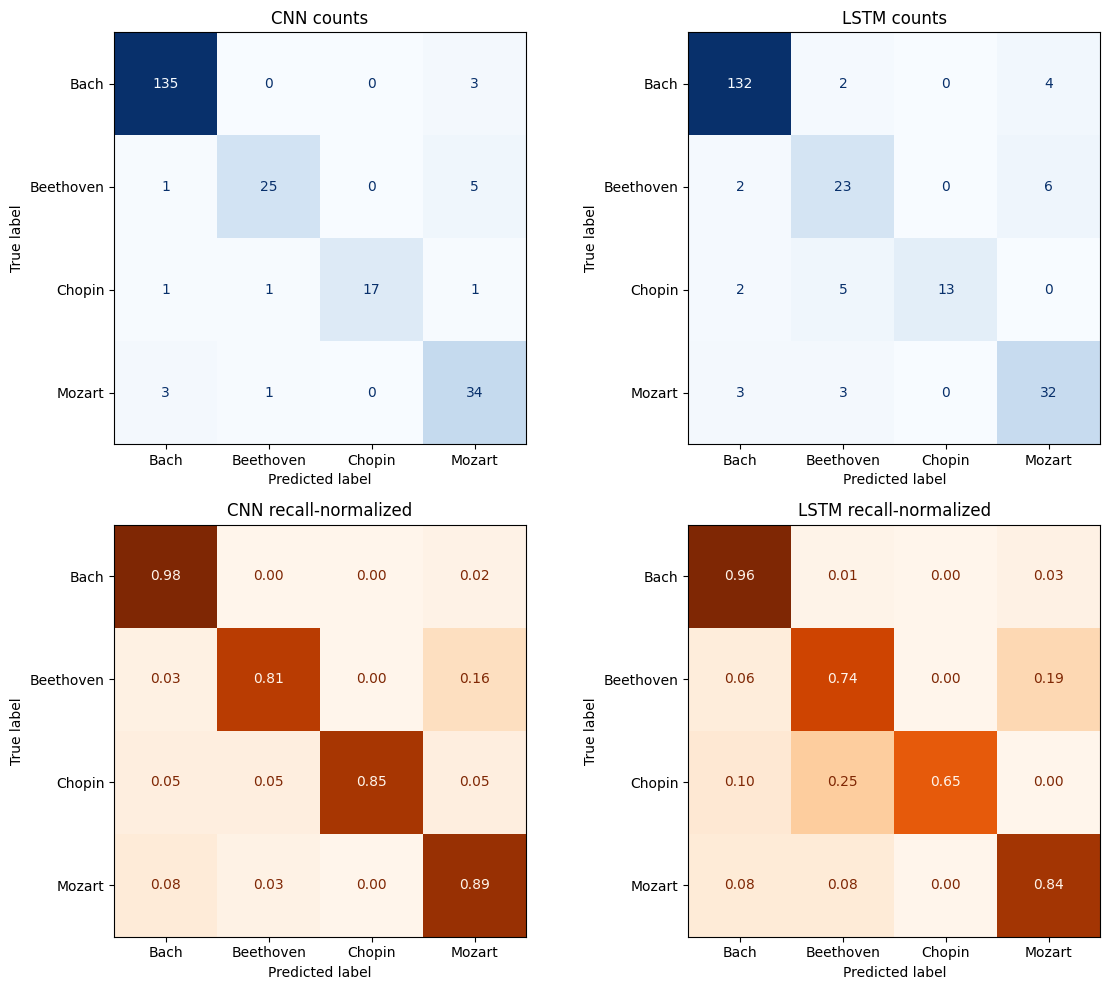

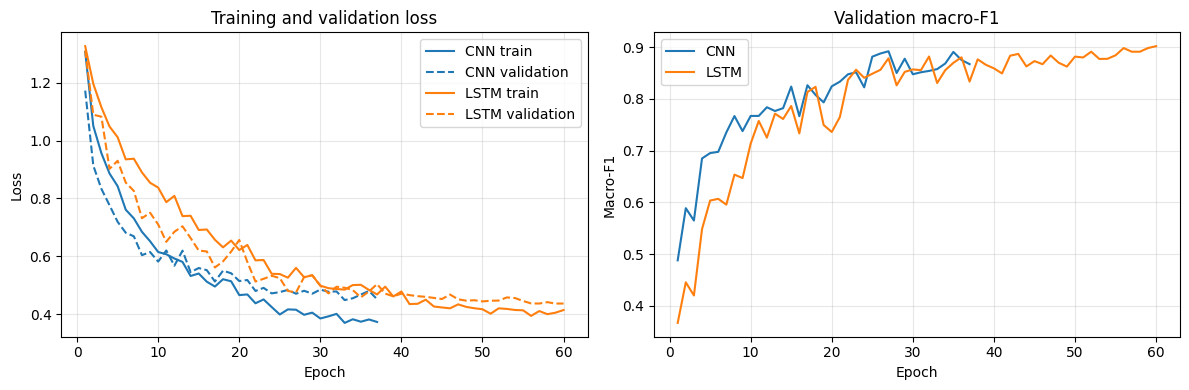

In [50]:
# Compare CNN and LSTM using exactly one source-level prediction per MIDI file.
# Macro-F1 is the checkpoint-selection metric; accuracy and AUC are secondary.

label_indices = np.arange(NUM_CLASSES)
summary_rows = []
per_class_rows = []

for model_name, metrics in test_results.items():
    source_count = len(metrics["source_ids"])
    expected_sources = test_df["source_id"].nunique()
    if source_count != expected_sources:
        raise AssertionError(
            f"{model_name} has {source_count} predictions, expected {expected_sources} sources."
        )

    output_dir = SEPARATE_MODEL_DIR / model_name.lower()
    predictions_df = pd.DataFrame(
        {
            "source_id": metrics["source_ids"],
            "chunk_count": metrics["chunk_counts"],
            "true_label_index": metrics["targets"],
            "pred_label_index": metrics["predictions"],
            "true_composer": [index_to_label[index] for index in metrics["targets"]],
            "pred_composer": [index_to_label[index] for index in metrics["predictions"]],
        }
    )
    for class_index, composer in index_to_label.items():
        predictions_df[f"prob_{composer}"] = metrics["probabilities"][:, class_index]
    predictions_df.to_csv(output_dir / "test_predictions.csv", index=False)

    summary_rows.append(
        {
            "model": model_name,
            "parameters": sum(
                parameter.numel() for parameter in trained_models[model_name].parameters()
            ),
            "selected_epoch": validation_summaries[model_name]["best_epoch"],
            "validation_macro_f1": validation_summaries[model_name]["best_val_macro_f1"],
            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "test_macro_auc_ovr": metrics["macro_auc_ovr"],
            "minimum_class_f1": metrics["min_class_f1"],
            "minimum_class_recall": metrics["min_class_recall"],
            "test_sources": source_count,
            "mean_chunks_per_source": metrics["chunk_counts"].mean(),
            "max_chunks_per_source": metrics["chunk_counts"].max(),
        }
    )

    for class_index, composer in index_to_label.items():
        per_class_rows.append(
            {
                "model": model_name,
                "composer": composer,
                "precision": metrics["precision_by_class"][class_index],
                "recall": metrics["recall_by_class"][class_index],
                "f1": metrics["f1_by_class"][class_index],
                "support": metrics["support_by_class"][class_index],
            }
        )

    print("\n" + "=" * 72)
    print(f"{model_name} TEST CLASSIFICATION REPORT (SOURCE LEVEL)")
    print("=" * 72)
    print(
        classification_report(
            metrics["targets"],
            metrics["predictions"],
            labels=label_indices,
            target_names=composer_names,
            digits=4,
            zero_division=0,
        )
    )

experiment_summary = pd.DataFrame(summary_rows).sort_values(
    "validation_macro_f1",
    ascending=False,
)
per_class_summary = pd.DataFrame(per_class_rows).sort_values(["model", "composer"])
experiment_summary.to_csv(SEPARATE_MODEL_DIR / "experiment_summary.csv", index=False)
per_class_summary.to_csv(SEPARATE_MODEL_DIR / "per_class_test_metrics.csv", index=False)

print("\nExperiment summary:")
display(experiment_summary.round(4))
print("\nPer-class source-level metrics:")
display(per_class_summary.round(4))
print()

model_items = list(test_results.items())
fig, axes = plt.subplots(2, len(model_items), figsize=(6 * len(model_items), 10))
axes = np.asarray(axes).reshape(2, -1)
for column, (model_name, metrics) in enumerate(model_items):
    count_matrix = confusion_matrix(
        metrics["targets"],
        metrics["predictions"],
        labels=label_indices,
    )
    normalized_matrix = confusion_matrix(
        metrics["targets"],
        metrics["predictions"],
        labels=label_indices,
        normalize="true",
    )

    ConfusionMatrixDisplay(
        confusion_matrix=count_matrix,
        display_labels=composer_names,
    ).plot(ax=axes[0, column], cmap=plt.cm.Blues, colorbar=False, values_format="d")
    axes[0, column].set_title(f"{model_name} counts")
    print()

    ConfusionMatrixDisplay(
        confusion_matrix=normalized_matrix,
        display_labels=composer_names,
    ).plot(ax=axes[1, column], cmap=plt.cm.Oranges, colorbar=False, values_format=".2f")
    axes[1, column].set_title(f"{model_name} recall-normalized")

plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "confusion_matrices_source_level.png", dpi=150)
plt.show()
print()

# Training curves, including the macro-F1 used for checkpoint selection.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, history in training_histories.items():
    color = "tab:blue" if model_name == "CNN" else "tab:orange"
    axes[0].plot(history["epoch"], history["train_loss"], color=color, label=f"{model_name} train")
    axes[0].plot(
        history["epoch"],
        history["val_loss"],
        color=color,
        linestyle="--",
        label=f"{model_name} validation",
    )
    axes[1].plot(history["epoch"], history["val_macro_f1"], color=color, label=model_name)

axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SEPARATE_MODEL_DIR / "training_comparison.png", dpi=150)
plt.show()